# Predictive Maintenance: Machine Failure Classification V2
This builds on the V1 model (predictive_maintenance_classification.ipynb) by adding in following enhancements:

- Remove Random + Unknown Failure Types
- Better balance the data set between failures and no failures



## Installations

In [ ]:
import pandas as pd

import os

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [ ]:
## Dataset: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
df = pd.read_csv('ai4i2020.csv')

Using Colab cache for faster access to the 'predictive-maintenance-dataset-ai4i-2020' dataset.


## Column Name Clean Up

In [ ]:
df.columns = df.columns.str.replace(' ', '_', regex=False).str.lower()

## Add new columns that were created during the EDA in V1


In [ ]:
# Calculation to determine likelihood of osf
df['overstrain_metric'] = df['tool_wear_[min]'] * df['torque_[nm]']

# Difference helps detect hdf
df['temp_diff'] = df['process_temperature_[k]'] - df['air_temperature_[k]']

# Estimates power delivered by the machine and possible conditions leading to pwf
df['power_estimate'] = df['torque_[nm]'] * df['rotational_speed_[rpm]']

In [ ]:
# Create dummies based on type
type_dummies = pd.get_dummies(df['type'], prefix='type', dtype=int)
df = pd.concat([df, type_dummies], axis=1)

In [ ]:
# Approach to handling multiple failures per machine
# Prioritize failures based on safety and ability to predict
# If a machine has multiple failures instead of setting failure_type to "Multiple" and lose data
# set primary_failure based on prioritization

priority = ["pwf", "osf", "hdf", "twf", "rnf"]

def primary_failure(row):
  for f in priority:
    if row[f] == 1:
      return f.upper()
  if row["machine_failure"] == 1:
    return "Unknown"
  return "No Failure"

In [ ]:
df["primary_failure"] = df.apply(primary_failure, axis=1)

## Enhancements

In [ ]:
# Remove rows with an unknown failure type
df = df[df['primary_failure'] != 'Unknown']

In [ ]:
# Remove rows with a random failure type
df = df[df.primary_failure != "RNF"]

In [ ]:
# Balance data set
failures = df[df.primary_failure != "No Failure"]
no_failure = df[df.primary_failure == "No Failure"]

no_failure_downsampled = no_failure.sample(
    n=4 * len(failures),
    random_state=42
)

df_balanced = pd.concat([failures, no_failure_downsampled])

In [ ]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1650 entries, 50 to 9941
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      1650 non-null   int64  
 1   product_id               1650 non-null   object 
 2   type                     1650 non-null   object 
 3   air_temperature_[k]      1650 non-null   float64
 4   process_temperature_[k]  1650 non-null   float64
 5   rotational_speed_[rpm]   1650 non-null   int64  
 6   torque_[nm]              1650 non-null   float64
 7   tool_wear_[min]          1650 non-null   int64  
 8   machine_failure          1650 non-null   int64  
 9   twf                      1650 non-null   int64  
 10  hdf                      1650 non-null   int64  
 11  pwf                      1650 non-null   int64  
 12  osf                      1650 non-null   int64  
 13  rnf                      1650 non-null   int64  
 14  overstrain_metric        165

## Objective

To predict machine failures before they occur so manufacturers can perform proactive maintenance.

Target: `primary_failure` (e.g., TWF, OSF, PWF, HDF, No Failure).

Prioritize recall for failures. A false negative (predicting no failure when one occurs) is far costly than a false positive as it is unscheduled maintenance, introduces emergency repairs, and potential safety hazard.

In [ ]:
target = df_balanced['primary_failure']

## Feature Selection

Kept the same as V1

In [ ]:
features = df_balanced[['rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'overstrain_metric', 'temp_diff', 'power_estimate', 'type_H', 'type_M', 'type_L']]

## Model Evaluation

Explore and compare models using:
* KNN
* Logistic Regression
* Decision Tree
* Random Forest
* Bagged Decision Trees

Each model will have a:
* Pipeline
* Param Grid
* Scorer = recall_weighted
* CV

Then the grid will be fitted on the features and target. And the best_params and cross_val_score for the grid will be printed to evaluate the model

### KNN

In [ ]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 10],
    'knn__weights': ['uniform', 'distance']
}

In [ ]:
knn_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="recall_weighted",
    cv=knn_cv
)

In [ ]:
knn_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7, 10],
                         'knn__weights': ['uniform', 'distance']},
             scoring='recall_weighted')

In [ ]:
print(knn_grid.best_params_)

{'knn__n_neighbors': 7, 'knn__weights': 'distance'}


In [ ]:
knn_scores = cross_val_score(
    estimator=knn_pipeline,
    X=features,
    y=target,
    cv=knn_cv,
    scoring="recall_weighted"
)

In [ ]:
print(knn_scores)
print(knn_scores.mean())

[0.92121212 0.91515152 0.91515152 0.91515152 0.90606061]
0.9145454545454544


### Logistic Regression

In [ ]:
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

logreg_param_grid = {
  'logreg__C': [0.01, 0.1, 1, 10],
  'logreg__penalty': ['l2']
}

In [ ]:
logreg_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="recall_weighted",
    cv=logreg_cv
)

In [ ]:
logreg_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'logreg__C': [0.01, 0.1, 1, 10],
                         'logreg__penalty': ['l2']},
             scoring='recall_weighted')

In [ ]:
print(logreg_grid.best_params_)

{'logreg__C': 10, 'logreg__penalty': 'l2'}


In [ ]:
logreg_scores = cross_val_score(
    estimator=logreg_pipeline,
    X=features,
    y=target,
    cv=logreg_cv,
    scoring="recall_weighted"
)

In [ ]:
print(logreg_scores)
print(logreg_scores.mean())

[0.93333333 0.92424242 0.94545455 0.92424242 0.94848485]
0.9351515151515152


### Decision Trees

In [ ]:
dt_pipeline = Pipeline([ ('classifier', DecisionTreeClassifier())])
dt_param_grid = {
  'classifier__max_depth': [3, 5, 7, 10],
  'classifier__min_samples_split': [2, 5, 10],
  'classifier__min_samples_leaf': [1, 2, 4],
  'classifier__criterion': ['gini', 'entropy']
}

In [ ]:
dt_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="recall_weighted",
    cv=dt_cv
)

In [ ]:
dt_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        DecisionTreeClassifier())]),
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 7, 10],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='recall_weighted')

In [ ]:
print(dt_grid.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}


In [ ]:
dt_scores = cross_val_score(
    estimator=dt_pipeline,
    X=features,
    y=target,
    cv=dt_cv,
    scoring="recall_weighted"
)

In [ ]:
print(dt_scores)
print(dt_scores.mean())

[0.95757576 0.96363636 0.97272727 0.96363636 0.95151515]
0.9618181818181817


### Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier())
])

# When running fit the first couple times it was taking over 5+ and there was no conclusion
# Therefore reduced the number of  param options to run
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 7],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__criterion': ['gini']
}

In [ ]:
# Reduced to 3 splits from 5 as the fitting was taking over 5 minutes to run
rf_cv = StratifiedKFold(n_splits=3, shuffle=True)

In [ ]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="recall_weighted",
    cv=rf_cv,
    n_jobs=1, # To help with performance when running locally
)

In [ ]:
rf_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        RandomForestClassifier())]),
             n_jobs=1,
             param_grid={'classifier__criterion': ['gini'],
                         'classifier__max_depth': [5, 7],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='recall_weighted')

In [ ]:
print(rf_grid.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}


In [ ]:
rf_scores = cross_val_score(
    estimator=rf_pipeline,
    X=features,
    y=target,
    cv=rf_cv,
    scoring="recall_weighted"
)

In [ ]:
print(rf_scores)
print(rf_scores.mean())

[0.97272727 0.96727273 0.96909091]
0.9696969696969697


### Bagged Decision Trees

In [ ]:
bag_pipeline = Pipeline([
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier()
    ))
])

# When running fit the first couple times it was taking over 5+ and there was no conclusion
# Therefore reduced the number of  param options to run
bag_param_grid = {
    'classifier__n_estimators': [10, 50],
    'classifier__max_samples': [0.7, 1.0],
    'classifier__max_features': [0.7, 1.0],
    'classifier__estimator__max_depth': [3, 5],
    'classifier__estimator__min_samples_split': [2, 5]
}

In [ ]:
# Reduced to 3 splits from 5 as the fitting was taking over 5 minutes to run
bag_cv = StratifiedKFold(n_splits=3, shuffle=True)

In [ ]:
bag_grid = GridSearchCV(
    estimator=bag_pipeline,
    param_grid=bag_param_grid,
    scoring="recall_weighted",
    cv=bag_cv,
    n_jobs=1 # To help with performance running a fit
)

In [ ]:
bag_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        BaggingClassifier(estimator=DecisionTreeClassifier()))]),
             n_jobs=1,
             param_grid={'classifier__estimator__max_depth': [3, 5],
                         'classifier__estimator__min_samples_split': [2, 5],
                         'classifier__max_features': [0.7, 1.0],
                         'classifier__max_samples': [0.7, 1.0],
                         'classifier__n_estimators': [10, 50]},
             scoring='recall_weighted')

In [ ]:
print(bag_grid.best_params_)

{'classifier__estimator__max_depth': 5, 'classifier__estimator__min_samples_split': 5, 'classifier__max_features': 1.0, 'classifier__max_samples': 1.0, 'classifier__n_estimators': 10}


In [ ]:
bag_scores = cross_val_score(
    estimator=bag_pipeline,
    X=features,
    y=target,
    cv=bag_cv,
    scoring="recall_weighted"
)

In [ ]:
print(bag_scores)
print(bag_scores.mean())

[0.96727273 0.95636364 0.95818182]
0.9606060606060606


### Observations

| Model                 | CV Mean Accuracy |
| --------------------- | ---------------- |
| KNN                   | 0.9145           |
| Logistic Regression   | 0.9352           |
| Decision Tree         | 0.9618           |
| Random Forest         | 0.9697           |
| Bagged Decision Trees | 0.9606           |





Top performers: Random Forest and Decision Trees

Final decision: Random Forest as it has the best overall performance, and interpretability.

## Final Model

Random Forest

Best Params:
```
{'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

```

In [ ]:
final_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        criterion='gini',
        max_depth=7,
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=50,
    ))
])

In [ ]:
final_pipeline.fit(features, target)

Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_depth=7, n_estimators=50))])

In [ ]:
final_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
predicted_failures = cross_val_predict(final_pipeline, features, target, cv=final_cv)

In [ ]:
# Classification Report as a Summary
print(classification_report(target, predicted_failures))

              precision    recall  f1-score   support

         HDF       0.99      0.99      0.99       106
  No Failure       0.97      0.99      0.98      1320
         OSF       0.93      1.00      0.97        86
         PWF       0.99      0.99      0.99        95
         TWF       0.18      0.05      0.07        43

    accuracy                           0.97      1650
   macro avg       0.81      0.80      0.80      1650
weighted avg       0.95      0.97      0.96      1650



### Predictions vs. Actuals


In [ ]:
df_balanced['predicted_failure'] = predicted_failures

In [ ]:
df_balanced.sample(10)

,udi,product_id,type,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,...,overstrain_metric,temp_diff,power_estimate,type_H,type_L,type_M,primary_failure,predicted_failure,actual_binary,pred_binary
5652,5653,L52832,L,302.4,311.8,1727,26.5,213,0,0,...,5644.5,9.4,45765.5,0,1,0,No Failure,TWF,No Failure,No Failure
304,305,L47484,L,297.8,308.4,1737,27.5,146,0,0,...,4015.0,10.6,47767.5,0,1,0,No Failure,No Failure,No Failure,No Failure
4527,4528,M19387,M,302.4,310.5,1372,45.7,144,1,0,...,6580.8,8.1,62700.4,0,0,1,HDF,HDF,Failure,Failure
527,528,M15387,M,297.6,309.6,1592,35.8,57,0,0,...,2040.6,12.0,56993.6,0,0,1,No Failure,No Failure,No Failure,No Failure
7941,7942,M22801,M,300.7,311.7,1499,38.9,3,0,0,...,116.7,11.0,58311.1,0,0,1,No Failure,No Failure,No Failure,No Failure
3519,3520,M18379,M,301.9,310.9,1569,32.5,188,0,0,...,6110.0,9.0,50992.5,0,0,1,No Failure,No Failure,No Failure,No Failure
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,...,413.0,9.6,47318.0,0,0,1,No Failure,No Failure,No Failure,No Failure
5343,5344,L52523,L,303.5,312.8,1607,38.4,92,0,0,...,3532.8,9.3,61708.8,0,1,0,No Failure,No Failure,No Failure,No Failure
3211,3212,L50391,L,300.3,309.2,1462,51.4,48,0,0,...,2467.2,8.9,75146.8,0,1,0,No Failure,No Failure,No Failure,No Failure
6990,6991,L54170,L,300.7,311.1,2478,13.4,170,1,0,...,2278.0,10.4,33205.2,0,1,0,PWF,PWF,Failure,Failure


In [ ]:
# How many predictions were correct?
correct_prediction = predicted_failures == target
print(correct_prediction.value_counts())

primary_failure
True     1593
False      57
Name: count, dtype: int64


Of 1,650 datapoints, 1,593 were predicted correctly and 57 were predicted incorrectly. 27 records were removed from the data set and the data set was balanced to:
* Failures: 330
* No Failure sampled: 1320
* Total training rows: 1650



In [ ]:
correctly_detected_failures = df_balanced[
    (df_balanced['primary_failure'] != 'No Failure') &
    (df_balanced['predicted_failure'] == df_balanced['primary_failure'])
]

In [ ]:
num_correct_failures = len(correctly_detected_failures)

In [ ]:
num_total_failures = len(df_balanced[df_balanced['primary_failure'] != 'No Failure'])

In [ ]:
failure_recall = num_correct_failures / num_total_failures
failure_recall

0.8696969696969697

When reviewing only actual failures, the model achieves a recall of 0.869, indicating that it correctly identifies approximately 4 out of 5 failures.

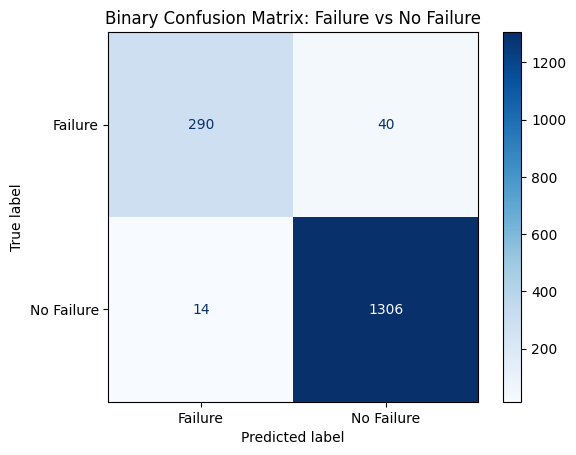

In [ ]:
df_balanced['actual_binary'] = df_balanced['primary_failure'].apply(lambda x: 'Failure' if x != 'No Failure' else 'No Failure')
df_balanced['pred_binary'] = df_balanced['predicted_failure'].apply(lambda x: 'Failure' if x != 'No Failure' else 'No Failure')
cm = confusion_matrix(df_balanced['actual_binary'], df_balanced['pred_binary'], labels=['Failure', 'No Failure'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'No Failure'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Binary Confusion Matrix: Failure vs No Failure")
plt.show()

In [ ]:
cm

array([[ 290,   40],
       [  14, 1306]])

While the model is multi-class, I evaluated performance in a binary sense (Failure vs No Failure) to summarize recall and false alarms across all failure types.

Of 330 actual failures, 290 were correctly detected (True Positives) and 40 were missed (False Negatives), resulting in a failure recall of 0.879.

False alarms were minimal, with 14 False Positives resulting in a precision of 0.954.

#### How many failures were missed?
40

In [ ]:
missed_failures = df_balanced[(df_balanced['primary_failure'] != 'No Failure') &
                     (df_balanced['predicted_failure'] != df_balanced['primary_failure'])]

In [ ]:
missed_counts = missed_failures.groupby('primary_failure').size().sort_values(ascending=False)
print(missed_counts)

primary_failure
TWF    41
HDF     1
PWF     1
dtype: int64


In [ ]:
missed_failures[['product_id', 'primary_failure', 'rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'overstrain_metric', 'temp_diff', 'power_estimate', ]]

,product_id,primary_failure,rotational_speed_[rpm],torque_[nm],tool_wear_[min],overstrain_metric,temp_diff,power_estimate
77,L47257,TWF,1455,41.3,208,8590.4,10.1,60091.5
1087,H30501,TWF,1549,35.8,206,7374.8,10.9,55454.2
1509,L48689,TWF,1429,37.7,220,8294.0,10.5,53873.3
1682,H31096,TWF,1604,36.1,225,8122.5,9.5,57904.4
1763,L48943,TWF,1511,31.0,209,6479.0,9.4,46841.0
1996,M16856,TWF,1416,38.2,198,7563.6,9.6,54091.2
2244,M17104,TWF,1542,37.5,203,7612.5,9.1,57825.0
2671,M17531,TWF,1399,41.9,221,9259.9,9.6,58618.1
2864,H32278,TWF,1380,47.6,246,11709.6,8.8,65688.0
2941,M17801,TWF,1996,19.8,203,4019.4,8.9,39520.8


The majority of missed failures are TWF, occurs at a "randomly selected tool wear time between 200-240 mins." This inherent randomness can make it harder to predict purely based on the other features provided.

#### How many false alarms were there?
14

In [ ]:
false_alarms = df_balanced[(df_balanced['primary_failure'] == 'No Failure') &
                  (df_balanced['predicted_failure'] != 'No Failure')]

In [ ]:
false_alarms[['product_id', 'predicted_failure', 'rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'overstrain_metric', 'temp_diff', 'power_estimate' ]]

,product_id,predicted_failure,rotational_speed_[rpm],torque_[nm],tool_wear_[min],overstrain_metric,temp_diff,power_estimate
5652,L52832,TWF,1727,26.5,213,5644.5,9.4,45765.5
329,H29743,TWF,1720,29.9,210,6279.0,10.8,51428.0
4380,L51560,OSF,1410,49.0,223,10927.0,7.7,69090.0
1590,L48770,TWF,1497,37.7,207,7803.9,10.2,56436.9
4118,L51298,HDF,1366,47.7,206,9826.2,8.6,65158.2
1332,L48512,TWF,1868,24.0,221,5304.0,11.3,44832.0
3856,M18716,OSF,1330,58.6,201,11778.6,8.8,77938.0
4294,M19154,TWF,1743,27.3,210,5733.0,8.4,47583.9
5395,L52575,TWF,1529,36.8,237,8721.6,9.6,56267.2
8356,M23216,OSF,1344,59.4,200,11880.0,11.0,79833.6


### Feature Importances
Identifies which inputs the Random Forest relied on most to predict machine failures. Features with a higher importance contributed more to the model's decisions.

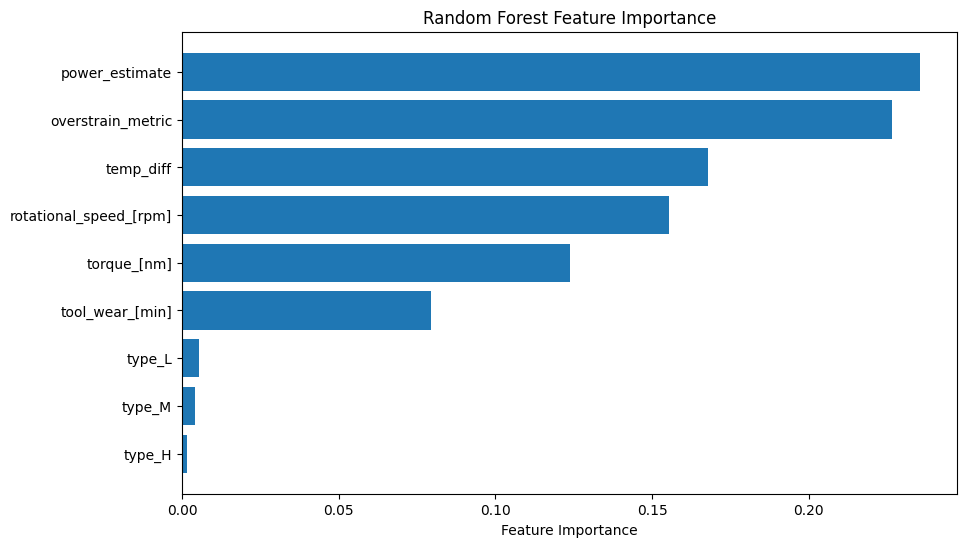

In [ ]:
forest = final_pipeline.named_steps['classifier']
importances = forest.feature_importances_
feature_names = features.columns

feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_df = feature_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_df['feature'], feature_df['importance'])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()


Top features that impact the model's decisions:

1. overstrain_metric: combines torque and tool wear to identify overstrain
2. power_estimate: which captures overall machine load and usage

## Further Enhancements

- Extend the model to predict multiple simultaneous failures per machine, rather than only the prioritized primary_failure.